# Import Needed Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import VGG16
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import CategoricalAccuracy, Precision, Recall
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2024-04-28 23:07:26.595171: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-04-28 23:07:26.667433: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-28 23:07:26.667505: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-28 23:07:26.670037: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-28 23:07:26.687406: I tensorflow/core/platform/cpu_feature_guar

# Check if there's a GPU available

In [2]:
def print_cuda_device():
    print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
    print("Eager mode: ", tf.executing_eagerly())
    print("GPU is", f"available" if tf.config.experimental.list_physical_devices('GPU') else "NOT AVAILABLE")

print_cuda_device()

Num GPUs Available:  1
Eager mode:  True
GPU is available


2024-04-28 23:07:29.851145: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-28 23:07:29.905168: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-28 23:07:29.905219: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.


# A. Data Loading, Exploration, and Preprocessing

[LO 3, 5 poin] Lakukan eksplorasi terhadap data tersebut dengan melihat histogram warnanya
dan lakukan proses augmentasi data jika diperlukan. Dan kemudian lakukan resize resolusi
gambar menjadi 224 x 224. Pisahkan dataset menjadi 80% training set, 10% validation set dan 
10% test set

## Data Loading

The data will be loaded from local file in the "data" directory. The data will be in the forms of folders containing images of the respective classes. For data exploration, the dataset will be loaded with `tf.keras.preprocessing.image_dataset_from_directory` and resized into 224 x 224 pixels. Then will be split into 80% training, 10% validation, and 10% test set.

### Creating the Data Pipeline

#### Check if data is available

In [3]:
dataPath = 'data'

# Check if data path exists
if not os.path.exists(dataPath):
    print(f"{dataPath} does not exist. Creating it...")
    os.makedirs(dataPath)
else:
    print(f"{dataPath} exists.")
    
# Check if data is empty or not
if not os.listdir(dataPath):
    print(f"{dataPath} is empty. Please add data to it.")
else:
    print(f"{dataPath} is not empty. Good to go.")


data exists.
data is not empty. Good to go.


#### Load the data using `tf.keras.preprocessing.image_dataset_from_directory`

In [4]:
Image_size = (224, 224)
batch_size = 8

In [5]:
ds = tf.keras.preprocessing.image_dataset_from_directory(
    directory=dataPath,
    labels='inferred',
    label_mode='categorical',
    image_size=Image_size,
    batch_size=batch_size,
    seed = SEED,
)

Found 1600 files belonging to 4 classes.


2024-04-28 23:07:31.128191: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-28 23:07:31.128279: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-28 23:07:31.128303: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-28 23:07:31.290003: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-28 23:07:31.290065: I external/local_xla/xla/stream_executor

## Data Exploration

#### Visualize the data

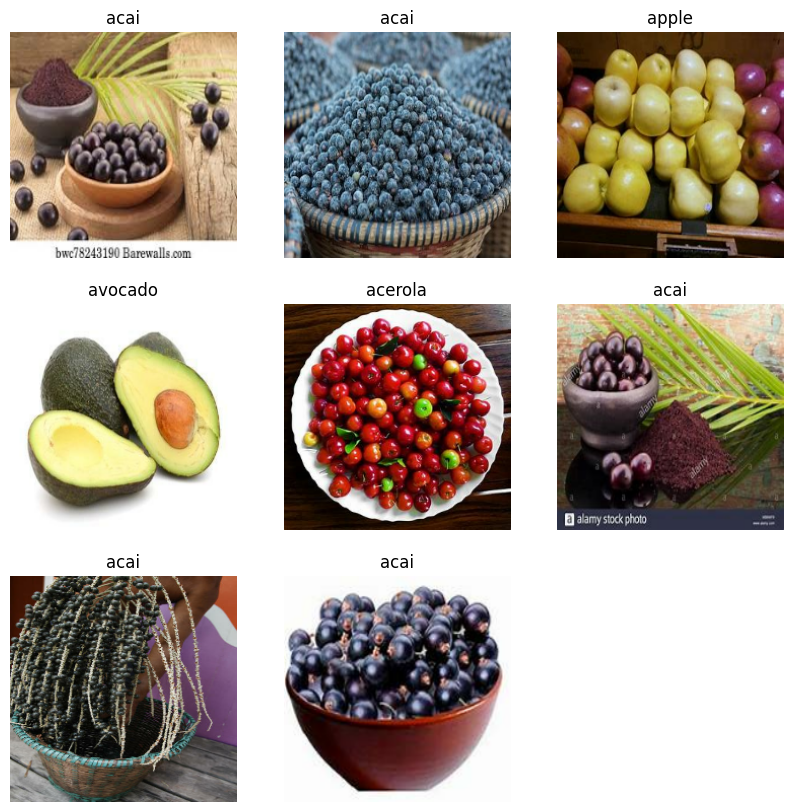

In [6]:
plt.figure(figsize=(10, 10))

for images, labels in ds.take(1):
    for i in range(len(images)):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(ds.class_names[labels[i].numpy().argmax()])
        plt.axis("off")

plt.show()

#### Inspect the Data

In [7]:
for image, label in ds.take(1):
    print(f"Batch Size, Image Shape (Width, Height), Color Channels: {image.shape}")
    print(f"Batch Size, Num of Labels: {label.shape}")

Batch Size, Image Shape (Width, Height), Color Channels: (8, 224, 224, 3)
Batch Size, Num of Labels: (8, 4)


### Check Class Distribution

#### Plotting data RGB Composition

In [8]:
def plotRGBComp(dataset, title: str):
    redSum = 0
    greenSum = 0
    blueSum = 0
    
    for image, label in dataset:
        redSum += np.sum(image[:, :, :, 0])
        greenSum += np.sum(image[:, :, :, 1])
        blueSum += np.sum(image[:, :, :, 2])
    
    values = [redSum, greenSum, blueSum]
    labels = ["red", "green", "blue"]
    colors = ["red", "green", "blue"]

    plt.figure(figsize=(10, 8))
    plt.bar(labels, values, color = colors)
    plt.title(f"The RGB Values of {title}")
    plt.xlabel("Color Channels")
    plt.ylabel("Sum Aggregate (Values)")
    plt.show

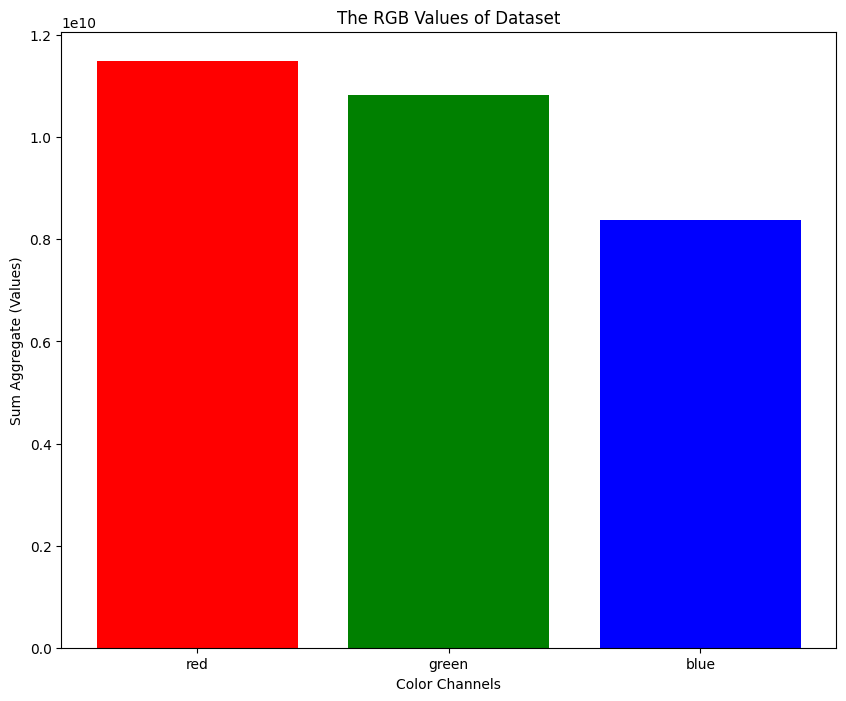

In [9]:
plotRGBComp(ds, "Dataset")

From the bar plot, we can see that most of the images have a near balanced composition of RGB colors, with red being the most, followed by green and blue subsequently.

## Data Preprocessing

### Data Splitting

Orginally the splitting will be done using `split_dataset` from `tf.keras.utils`. The splitting will be done with 80% training, 10% validation, and 10% test set. But because of lack of memory, we will clear the ds dataset and load a new train_ds and val_ds using `tf.keras.preprocessing.image_dataset_from_directory` dataset and split the val_ds dataset into val_ds and test_ds

#### Clearing ds dataset

In [10]:
ds = None

In [11]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    directory=dataPath,
    labels='inferred',
    validation_split=0.2,
    label_mode="categorical",
    subset="training",
    seed=SEED,
    image_size=Image_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    directory=dataPath,
    labels='inferred',
    validation_split=0.2,
    label_mode="categorical",
    subset="validation",
    seed=SEED,
    image_size=Image_size,
    batch_size=batch_size
)

Found 1600 files belonging to 4 classes.
Using 1280 files for training.
Found 1600 files belonging to 4 classes.
Using 320 files for validation.


In [12]:
test_ds, val_ds = tf.keras.utils.split_dataset(val_ds, left_size=0.5, right_size=0.5, shuffle=True,seed=SEED)

#### Check for Cardinality

In [13]:
train_ds.cardinality().numpy(), test_ds.cardinality().numpy(), val_ds.cardinality().numpy()

(160, 20, 20)

## Post-PreProcessing Visualization

### Check for RGP Comp

#### Training Set

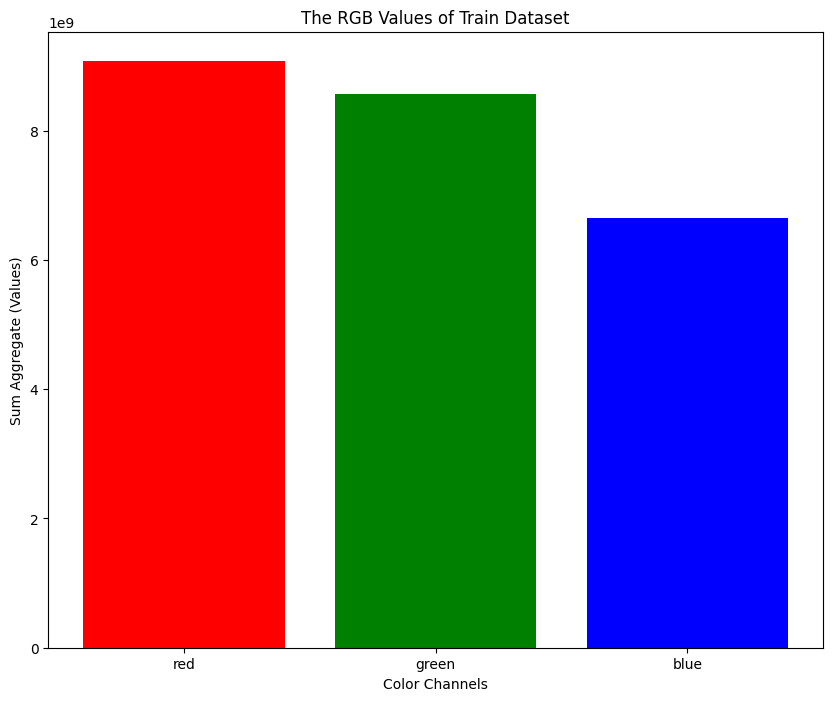

In [14]:
plotRGBComp(train_ds, "Train Dataset")

#### Test Set

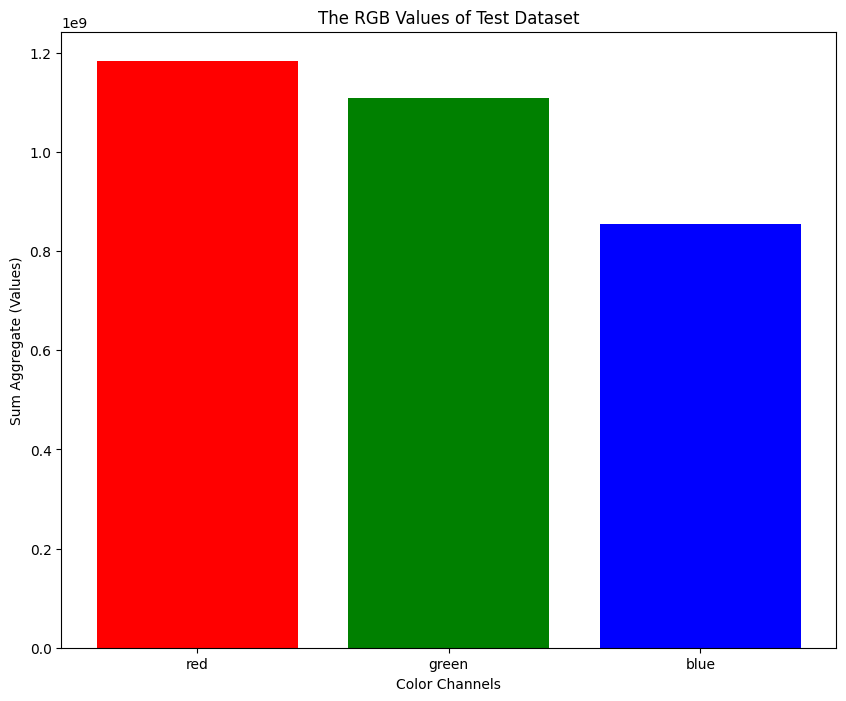

In [15]:
plotRGBComp(test_ds, "Test Dataset")

#### Validation Set

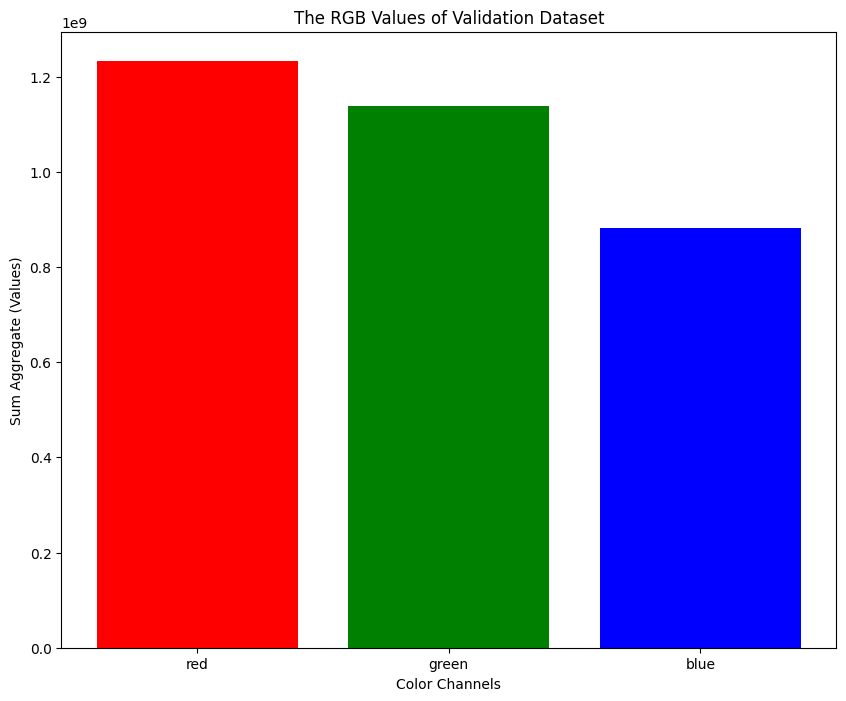

In [16]:
plotRGBComp(val_ds, "Validation Dataset")

# B. Challenges in The Data

From the data exploration, we can see that the data is imbalanced. The data is imbalanced because the RGB composition of the images is not equal. This can be seen from the bar plot of the RGB composition of the images. But the imbalance of the data is still negligeble so we will not do any augmentation from the dataset. But to minimize underfitting and overfitting we will implement Batch Normalization on the 2nd Model.

# C. Base Model Building

[LO 3, 15 poin] Buatlah arsitektur baseline sesuai dengan gambar arsitektur VGG-16 berikut ini:
(Catatan: Activation function tiap hidden layer menggunakan ReLU). Jelaskan mengenai model 
pretained dari VGG-16 yang digunakan dan metode fine-tuning yang dilakukan

## Prepare Output Directory

In [17]:
output_dir = "output/"

import time
now = time.strftime("%Y%m%d-%H%M%S", time.localtime())

model_name = now+"VGG16"
modelSave_dir = output_dir + model_name + "/models/"
log_dir = output_dir + model_name + "/logs/"
result_dir = output_dir + model_name + "/results/"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(modelSave_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
os.makedirs(result_dir, exist_ok=True)

## Defining Custom Callback Function

We will use custom callback function for greater efficiency and flexibility in monitoring the training process.

In [18]:
def createModel (model_name):
    return ModelCheckpoint(
        modelSave_dir + model_name + ".h5",
        verbose=1,
        monitor='val_loss',
        include_optimizer=False,
        #save_best_only=True
        mode='auto'
    )
    
def createLogger (model_name):
    return CSVLogger(
        log_dir + model_name + ".csv".format(model_name),
        append=True,
        separator=','
    )
    
class custom_EarlyStopping (tf.keras.callbacks.Callback):
    def __init__(self, patience=0):
        super(custom_EarlyStopping, self).__init__()
        self.patience = patience
        # best_weights to store the weights at which the minimum loss occurs.
        self.best_weights = None
    
    def on_train_begin(self, logs=None):
        # The number of epoch it has waited when loss is no longer minimum.
        self.wait = 0
        # The epoch the training stops at.
        self.stopped_epoch = 0
        # Initialize the best as infinity.
        self.best_valLoss = np.inf
        self.best_loss = np.inf
    
    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get('val_loss')
        loss = logs.get('loss')
        
        # if both val loss and loss does not improve for n number of patience then stop training early
        if np.less(val_loss, self.best_valLoss) and np.less(loss, self.best_loss):
            self.best_valLoss = val_loss
            self.best_loss = loss
            self.wait = 0
            # Record the best weights if current results is better (less).
            self.best_weights = self.model.get_weights()
            self.model.save_weights(modelSave_dir + model_name[0:10] + ".h5")
            
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch = epoch
                self.model.stop_training = True
                print("Restoring model weights from the end of the best epoch.")
                self.model.set_weights(self.best_weights)
                print("Early stopping at epoch: ", self.stopped_epoch)
        
    def on_train_end(self, logs=None):
        if self.stopped_epoch > 0:
            print("Epoch %05d: early stopping" % (self.stopped_epoch + 1))
        print("Restoring model weights from the end of the best epoch.")
        self.model.set_weights(self.best_weights)
        
class timedStopping(tf.keras.callbacks.Callback):
    '''Stop training when enough time has passed.
    # Arguments
        seconds: maximum time before stopping.
        verbose: verbosity mode.
    '''
    
    def __init__(self, seconds=None, verbose=0):
        super(timedStopping, self).__init__()
        self.start_time = 0
        self.seconds = seconds
        self.verbose = verbose
        
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
    
    def on_epoch_end(self, epoch, logs=None):
        if time.time() - self.start_time > self.seconds:
            self.model.stop_training = True
            if self.verbose:
                print('Stopping after %s seconds.' % self.seconds)

## Base Model

For the base model we will use vgg16 pretrained model from keras `https://keras.io/api/applications/` , using pretrained `imagenet` and setting it so that the base model is untrainable (no change in weights) with the default learning rate, epoch of 10, and optimizer Adam

### Model Definition & Summary

In [19]:
Inputs = Input(shape=(Image_size[0], Image_size[1], 3))
base_model = VGG16(include_top=False, input_shape=(Image_size[0], Image_size[1], 3), weights='imagenet')(Inputs)
base_model.trainable = False

# Global average pooling to reduce the number of dimension
model1 = GlobalAveragePooling2D()(base_model)

# Output layer with 2 nodes (multiclass classification)
model1 = Dense(4, activation='softmax')(model1)

model1 = Model(inputs=Inputs, outputs=model1)
model1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 4)                 2052      
                                                                 
Total params: 14716740 (56.14 MB)
Trainable params: 14716740 (56.14 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Model Compiling

In [21]:
model1.compile(loss=CategoricalCrossentropy(), optimizer=Adam(), metrics=[CategoricalAccuracy(), Precision(), Recall()])

### Model Training

In [23]:
from datetime import datetime

epochs = 10
callbacks = [
    createModel(model_name),
    createLogger(model_name),
    custom_EarlyStopping(patience=5),
#    timedStopping(seconds=3600)
]

def trainModel(models, epochs: int, callbacks):
    timestamp1 = datetime.now()
    history = models.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=1)
    timestamp2 = datetime.now()

    print("Training time: ", timestamp2 - timestamp1)
    
    return history, timestamp2 - timestamp1

In [23]:
history, training_time = trainModel(models=model1, epochs=epochs, callbacks=callbacks)

Epoch 1/10


2024-04-28 22:56:46.494575: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-04-28 22:56:47.422728: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 898.56MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2024-04-28 22:56:47.811589: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 898.00MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2024-04-28 22:56:47.869249: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 898.00MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there co

160/160 [==============================] - ETA: 0s - loss: 5.1152 - categorical_accuracy: 0.2227 - precision: 0.1519 - recall: 0.0094
Epoch 1: saving model to output/20240428-225619VGG16/models/20240428-225619VGG16.h5


/home/wbchn/miniconda3/envs/TensorFlow-DLN/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


160/160 [==============================] - 110s 548ms/step - loss: 5.1152 - categorical_accuracy: 0.2227 - precision: 0.1519 - recall: 0.0094 - val_loss: 1.3858 - val_categorical_accuracy: 0.3063 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
160/160 [==============================] - ETA: 0s - loss: 1.3937 - categorical_accuracy: 0.2250 - precision: 0.2000 - recall: 7.8125e-04
Epoch 2: saving model to output/20240428-225619VGG16/models/20240428-225619VGG16.h5
160/160 [==============================] - 94s 587ms/step - loss: 1.3937 - categorical_accuracy: 0.2250 - precision: 0.2000 - recall: 7.8125e-04 - val_loss: 1.3863 - val_categorical_accuracy: 0.2188 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
160/160 [==============================] - ETA: 0s - loss: 1.3966 - categorical_accuracy: 0.2516 - precision: 0.1429 - recall: 0.0016
Epoch 3: saving model to output/20240428-225619VGG16/models/20240428-225619VGG16.h5
160/160 [============================

### Model Evaluation

In [19]:
def evaluateModel(history, model_name, training_time) :
    acc = history.history['categorical_accuracy']
    val_acc = history.history['val_categorical_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(0, len(acc))

    plt.plot(epochs, acc, 'r', label='Training accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.savefig(result_dir + model_name + "_accuracy.png".format(model_name), dpi=100)
    plt.show()

    plt.plot(epochs, loss, 'r', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()
    plt.savefig(result_dir + model_name + "_loss.png".format(model_name), dpi=100)
    plt.show()

    avg_train_acc = np.mean(acc)
    avg_val_acc = np.mean(val_acc)
    avg_train_loss = np.mean(loss)
    avg_val_loss = np.mean(val_loss)

    with(open(result_dir + model_name + "_results.txt", 'a')) as f:
        f.write("Training time: {}\n".format(training_time))
        f.write("Average training accuracy: {}\n".format(avg_train_acc))
        f.write("Average validation accuracy: {}\n".format(avg_val_acc))
        f.write("Average training loss: {}\n".format(avg_train_loss))
        f.write("Average validation loss: {}\n".format(avg_val_loss))

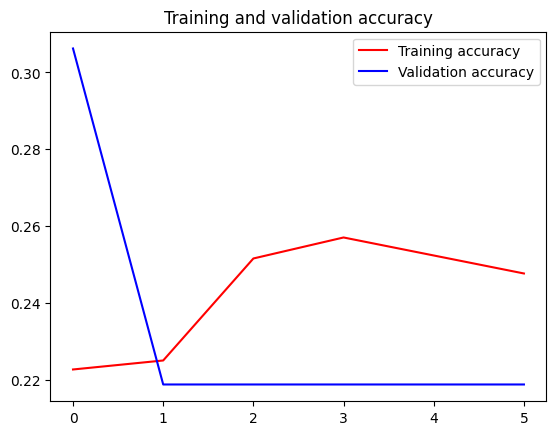

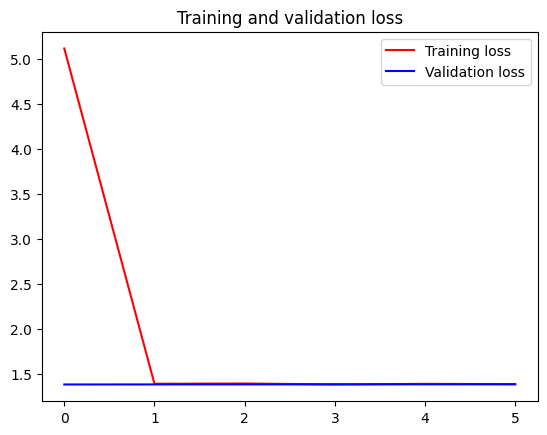

In [25]:
evaluateModel(history, model_name, training_time)

The low accuracy of the model that indicated underfitting could be caused by the sheer deepness and complexity of the model, which could be too much for the dataset to handle. For the 2nd model I will try to modify the model and tuning the learning rate to try to increase the accuracy.

# Modified Model

## Model 1
- Fine tuning with low learning rate
- Add Batch Normalization layer -> to mitigate overfitting

In [20]:
Inputs = Input(shape=(Image_size[0], Image_size[1], 3))
base_model = VGG16(include_top=False, input_shape=(Image_size[0], Image_size[1], 3), weights='imagenet')(Inputs)
base_model.trainable = True

# Global average pooling to reduce the number of dimension
model2 = GlobalAveragePooling2D()(base_model)
model2 = BatchNormalization()(model2)

# Output layer with 2 nodes (multiclass classification)
model2 = Dense(4, activation='softmax')(model2)

model2 = Model(inputs=Inputs, outputs=model2)
model2.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 batch_normalization (Batch  (None, 512)               2048      
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 4)                 2052      
                                                                 
Total params: 14718788 (56.15 MB)
Trainable params: 14717764 

In [21]:
model2.compile(loss=CategoricalCrossentropy(), optimizer=Adam(learning_rate=0.00001), metrics=[CategoricalAccuracy(), Precision(), Recall()])

In [24]:
from datetime import datetime

epochs = 100
callbacks = [
    createModel(model_name),
    createLogger(model_name),
    custom_EarlyStopping(patience=5),
#    timedStopping(seconds=3600)
]

history2, training_time2 = trainModel(model2, epochs, callbacks)

Epoch 1/100


2024-04-28 23:08:09.086626: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-04-28 23:08:09.861859: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 898.56MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2024-04-28 23:08:10.250592: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 898.00MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2024-04-28 23:08:10.308153: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 898.00MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there co

160/160 [==============================] - ETA: 0s - loss: 0.9601 - categorical_accuracy: 0.6242 - precision: 0.7036 - recall: 0.5414
Epoch 1: saving model to output/20240428-230743VGG16/models/20240428-230743VGG16.h5


/home/wbchn/miniconda3/envs/TensorFlow-DLN/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


160/160 [==============================] - 114s 559ms/step - loss: 0.9601 - categorical_accuracy: 0.6242 - precision: 0.7036 - recall: 0.5414 - val_loss: 0.5068 - val_categorical_accuracy: 0.8188 - val_precision: 0.8552 - val_recall: 0.7750
Epoch 2/100
160/160 [==============================] - ETA: 0s - loss: 0.3694 - categorical_accuracy: 0.8695 - precision: 0.8946 - recall: 0.8359
Epoch 2: saving model to output/20240428-230743VGG16/models/20240428-230743VGG16.h5
160/160 [==============================] - 91s 567ms/step - loss: 0.3694 - categorical_accuracy: 0.8695 - precision: 0.8946 - recall: 0.8359 - val_loss: 0.2408 - val_categorical_accuracy: 0.9000 - val_precision: 0.9338 - val_recall: 0.8813
Epoch 3/100
160/160 [==============================] - ETA: 0s - loss: 0.1998 - categorical_accuracy: 0.9414 - precision: 0.9565 - recall: 0.9273
Epoch 3: saving model to output/20240428-230743VGG16/models/20240428-230743VGG16.h5
160/160 [==============================] - 90s 561ms/step -

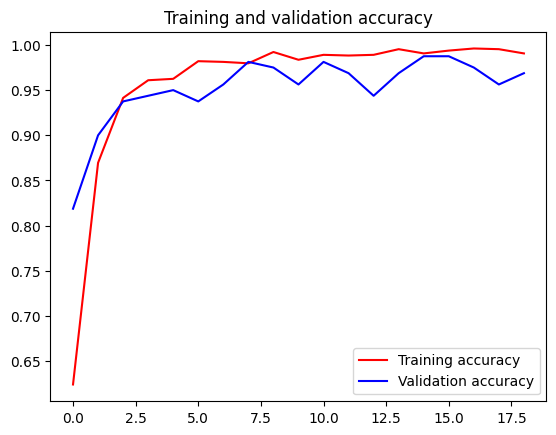

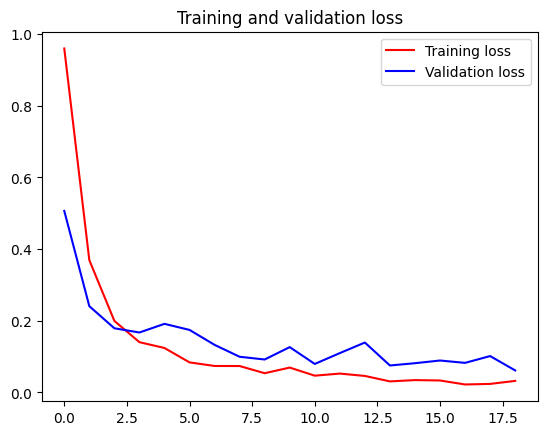

In [25]:
evaluateModel(history2, model_name, training_time2)

From the graph shown, the model doesn't seem to exhibit a substansial amount of overfitting and seem to be going for convergence.

# Model Evaluation

In [26]:
# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results = model2.evaluate(test_ds)
print("test loss, test acc:", results)

Evaluate on test data
20/20 [==============================] - 3s 136ms/step - loss: 0.1565 - categorical_accuracy: 0.9312 - precision: 0.9430 - recall: 0.9312
test loss, test acc: [0.15652868151664734, 0.9312499761581421, 0.9430379867553711, 0.9312499761581421]


The accuracy of 0.925 indicates that the model can accurately classify the images to 1 of 4 classes with 92.5% accuracy, 94% Precision, and 93% recall of which shows the model is performing great in predicting the class of each fruits.

## Create Inference of the Model

In [27]:
pred = model2.predict(test_ds.take(1))

1/1 [==============================] - 0s 270ms/step


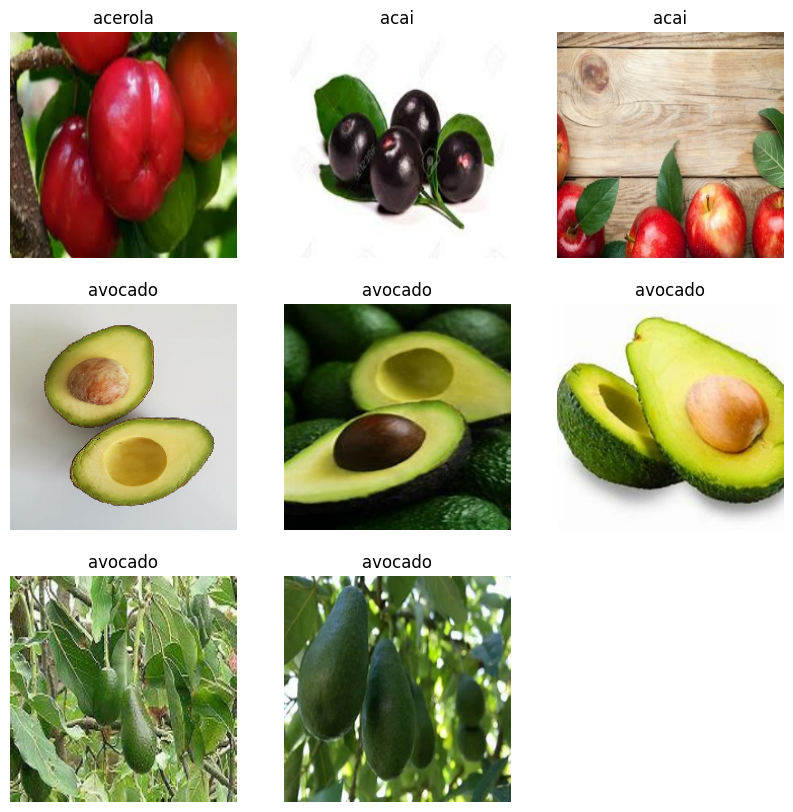

In [28]:
# Visualize images with it's vlass prediction
plt.figure(figsize=(10, 10))
label = ["acai", "acerola", "apple", "avocado"]

for images, labels in test_ds.take(1):
    for i in range(len(images)):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(label[pred[i].argmax()])
        plt.axis("off")

plt.show()